# Coursework: Image Matching
### Visual Computing

This notebook contains exercises related to Part Two of  Coursework 2: Rendering and Image Matching,  CM22010 Visual Computing. It consists of two tasks: image stitching and panorama stitching. 

**Grading Scheme (6 points total)**:

- Task 1 **Image Stitching**: 3 points
- Task 2 **Panorama Stitching**: 3 points




### 1. Task 1 Image Stitching (3 points)
Image stitching involves aligning TWO images together to create a larger composite.

Note: You have to use your custom code (without using pre-built OpenCV libraries which would give one line of code of image stitching).


**Task description:**
- Stitching of two images together by finding corresponding points, aligning the images using a transformation.
- Optional: use blending techniques (such as linear blending) to avoid visible seams where the images overlap.

Corners img1: 932
Corners img2: 1146


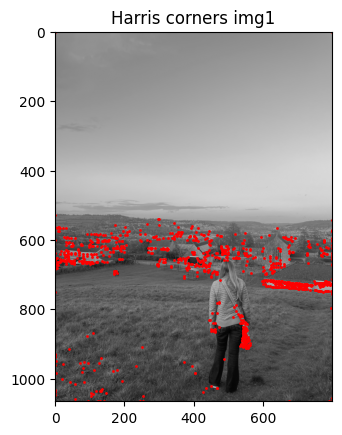

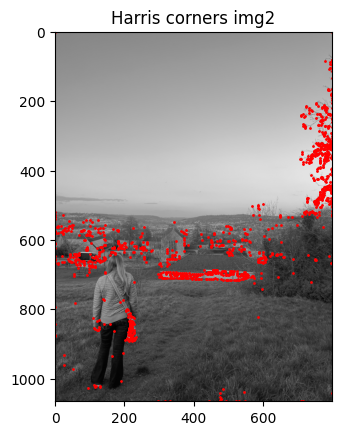

In [49]:
# Implement image stitching

# HELPFUL WEBSITE: https://kushalvyas.github.io/stitching.html
# 1. Image Registration
# 2. Calibration
# 3. Blending

import numpy as np
from PIL import Image 
import matplotlib.pyplot as plt

img1 = Image.open("images/IMG_2.jpeg").convert("L") # load img1 as greyscale
img1 = img1.rotate(270, expand=True) # get it correct orientation
img1 = img1.resize((800, int(800 * 4032 / 3024))) # resize for faster convolution
grey1 = np.array(img1, dtype=np.float32) # convert to numpy array

plt.imshow(grey1, cmap="gray")

img2 = Image.open("images/IMG_4.jpeg").convert("L") # load img2 as greyscale
img2 = img2.rotate(270, expand=True) # get it correct orientation
img2 = img2.resize((800, int(800 * 4032 / 3024)))# resize
grey2 = np.array(img2, dtype=np.float32) # convert to numpy array

sobel_x = np.array([
[-1,0,1],
[-2,0,2],
[-1,0,1]
])

sobel_y = np.array([
[-1,-2,-1],
[0,0,0],
[1,2,1]
])

def convolve(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad = kh // 2

    padded = np.pad(image, pad, mode="constant")
    result = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            result[i,j] = np.sum(region * kernel)
    
    return result

def find_harris_corners(image):

    # compute gradients
    imgx = convolve(image, sobel_x)
    imgy = convolve(image, sobel_y)

    # compute Harris matrix components
    imgx2 = imgx * imgx
    imgy2 = imgy * imgy
    imgxy = imgx * imgy

    # sum values in a window
    window = np.ones((3, 3))

    Sx2 = convolve(imgx2, window)
    Sy2 = convolve(imgy2, window)
    Sxy = convolve(imgxy, window)

    # compute harris corner response

    k = 0.04
    det = (Sx2 * Sy2) - (Sxy ** 2)
    trace = Sx2 + Sy2

    R = det - k * (trace ** 2)

    # non-maximum suppression
    suppressed = np.zeros_like(R)

    window_size = 3
    offset = window_size // 2

    h, w = R.shape

    for i in range(offset, h-offset):
        for j in range(offset, w-offset):
            region = R[i-offset:i+offset+1, j-offset:j+offset+1]

            if R[i, j] == np.max(region):
                suppressed[i, j] = R[i, j]

    # find corners
    threshold = 0.01 * suppressed.max()

    corners = np.zeros_like(suppressed)
    corners[suppressed > threshold] = 1

    # get corner coords
    points = np.argwhere(corners == 1)

    return points

points1 = find_harris_corners(grey1)
points2 = find_harris_corners(grey2)

print("Corners img1:", len(points1))
print("Corners img2:", len(points2))

# plot corners
plt.imshow(grey1, cmap="gray")

y1, x1 = points1[:,0], points1[:,1]
plt.scatter(x1, y1, s=1, c="red")

plt.title("Harris corners img1")
plt.show()

plt.imshow(grey2, cmap="gray")

y2, x2 = points2[:,0], points2[:,1]
plt.scatter(x2, y2, s=1, c="red")

plt.title("Harris corners img2")
plt.show()


# ------------- NOTES -------------
# TODO:
# - match features
# - compute homography
# - warp images
# - blend panorama


# find homography:
# compute similar features in both images
# out of them, filter out good features
# Make an array of; 
#   features of image 1 ==> [srcPoints], 
#   features of image 2 ==> [dstPoints]
# Compute homography matrix using RANSAC algorithm


### 2. Task 2 Panorama Stitching (3 points)
Panorama stitching involves aligning multiple images (minimally 3 images) to create a single wide-angle composite.

Note: You have to use your custom code (without using pre-built OpenCV libraries which would give one line of code of panorama stitching).

**Task description:**
- Implement panorama stitching with multiple images, at least three images.
- Use projective transformations to align images.
- Optional: You can explore techniques like feathering, linear blending for better panaromas.


In [48]:
# Code for Panorama Stitching here
# Implement panorama stitching techniques

import os

arrays = []

for file in os.listdir("images"):
    if file.endswith(".jpeg") or file.endswith(".jpg"):
        path = os.path.join("images", file)

        img = Image.open(path)
        gray = img.convert("L")
        arr = np.array(gray, dtype=np.float32)

        arrays.append(arr)

print(len(arrays))

5
